In [1]:
import pandas as pd
import numpy as np
from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
import numpy as np
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense, TimeDistributed, Lambda
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix
import time,tracemalloc


In [ ]:
path = '..../KDDTrain+.arff'
data, meta = arff.loadarff(path)
df = pd.DataFrame(data)
for col in df.select_dtypes([object]):
    df[col] = df[col].str.decode('utf-8')
df['label'] = (df[df.columns[-1]] != 'normal').astype(int)

In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct.round(2)
})

missing_cols = missing_df[missing_df['Missing Count'] > 0]

if missing_cols.empty:
    print("No missing values found.")
else:
    print(f"Missing values found in {len(missing_cols)} column(s):\n")
    print(missing_cols.to_string())

print(f"Total rows       : {len(df)}")
print(f"Total columns    : {df.shape[1]}")
print(f"Total missing    : {df.isnull().sum().sum()}")
print(f"Affected columns : {len(missing_cols)}")

No missing values found.
Total rows       : 125973
Total columns    : 43
Total missing    : 0
Affected columns : 0


In [5]:
selected_features = [
    'num_access_files',
    'dst_bytes',
    'dst_host_count',
    'num_compromised',
    'dst_host_same_srv_rate',
    'same_srv_rate',
    'dst_host_srv_count',
    'serror_rate',
    'count',
    'rerror_rate',
    'dst_host_srv_rerror_rate',
    'dst_host_srv_serror_rate',
    'dst_host_rerror_rate',
    'dst_host_same_src_port_rate',
    'dst_host_serror_rate',
    'num_file_creations',
    'srv_count',
    'srv_serror_rate',
    'srv_rerror_rate',
    'srv_diff_host_rate',
    'wrong_fragment',
    'urgent',
    'src_bytes',
    'hot',
    'num_failed_logins'
]

print(f"Total features: {len(selected_features)}")

Total features: 25


In [6]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
df['protocol_type'] = label_encoder.fit_transform(df['protocol_type'])
df['flag'] = label_encoder.fit_transform(df['flag'])

In [7]:
X = df[selected_features].values
y = df.iloc[:, 42].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [8]:
# --- JaspenCorrelation Layer ---
class JaspenCorrelation(tf.keras.layers.Layer):
    def call(self, inputs):
        t, r = inputs  # t: (None, feat_dim), r: (None, REF_COUNT, feat_dim)
        t_exp = tf.expand_dims(t, 1)  # (None, 1, feat_dim)
        dot = tf.reduce_sum(t_exp * r, axis=2)  # (None, REF_COUNT)

        sum_t = tf.reduce_sum(t_exp, axis=2)  # (None, 1)
        sum_r = tf.reduce_sum(r, axis=2)      # (None, REF_COUNT)

        n = tf.cast(tf.shape(t)[1], tf.float32)
        corr = (n * dot - sum_t * sum_r) / (tf.sqrt(n * sum_t) * tf.sqrt(n * sum_r) + 1e-8)
        return tf.maximum(corr, 0.0)  # only positive correlation

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

X_train = X_train.reshape(-1, X_train.shape[1], 1)
X_test = X_test.reshape(-1, X_test.shape[1], 1)

In [9]:
SEQ_LEN = X_train.shape[1]
CHANNELS = 1
REF_COUNT = 20
NUM_CLASSES = y_train.shape[1]

# --- Inputs ---
test_input = Input(shape=(SEQ_LEN, CHANNELS), name="test_input")
reference_input = Input(shape=(REF_COUNT, SEQ_LEN, CHANNELS), name="reference_input")

# --- Shared CNN ---
shared_cnn = tf.keras.Sequential([
    Conv1D(64, 3, activation='relu'),
    MaxPooling1D(2),
    Conv1D(128, 3, activation='relu'),
    MaxPooling1D(2),
    Flatten()
], name='shared_cnn')

# Apply shared CNN
test_encoded = shared_cnn(test_input)  # (None, feat_dim)
reference_encoded = TimeDistributed(shared_cnn)(reference_input)  # (None, REF_COUNT, feat_dim)

# --- Correlation ---
corr = JaspenCorrelation()([test_encoded, reference_encoded])  # (None, REF_COUNT)
agg = Lambda(lambda x: tf.reduce_mean(x, axis=1, keepdims=True))(corr)  # (None, 1)

# --- Dense Output ---
x = Dense(128, activation='relu')(agg)
output = Dense(NUM_CLASSES, activation='sigmoid')(x)

model = Model(inputs=[test_input, reference_input], outputs=output)

# Compile
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ test_input          │ (None, 25, 1)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reference_input     │ (None, 20, 25, 1) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ shared_cnn          │ (None, 512)       │     24,960 │ test_input[0][0]  │
│ (Sequential)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ time_distributed    │ (None, 20, 512)   │     24,960 │ reference_input[… │
│ (TimeDistributed)   │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ jaspen_correlation  │ (None, 20)        │          0 │ shared_cnn[0][0], │
│ (JaspenCorrelation) │                   │            │ time_distributed… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 1)         │          0 │ jaspen_correlati… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │        256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dense[0][0]       │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 25,474 (99.51 KB)

 Trainable params: 25,474 (99.51 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
reference_set = X_train[:REF_COUNT]
reference_input_train = np.repeat(reference_set[np.newaxis, :, :, :], X_train.shape[0], axis=0)
reference_input_test = np.repeat(reference_set[np.newaxis, :, :, :], X_test.shape[0], axis=0)
start = time.time()
tracemalloc.start()
# Train
history = model.fit(
    [X_train, reference_input_train],
    y_train,
    validation_data=([X_test, reference_input_test], y_test),
    epochs=10,
    batch_size=32
)
end = time.time()
current, peak = tracemalloc.get_traced_memory()
tracemalloc.stop()

Epoch 1/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 58s 12ms/step - accuracy: 0.9449 - loss: 0.1644 - val_accuracy: 0.9598 - val_loss: 0.1137
Epoch 2/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 39s 12ms/step - accuracy: 0.9608 - loss: 0.1037 - val_accuracy: 0.9633 - val_loss: 0.0970
Epoch 3/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 31s 9ms/step - accuracy: 0.9634 - loss: 0.0914 - val_accuracy: 0.9686 - val_loss: 0.0846
Epoch 4/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9666 - loss: 0.0834 - val_accuracy: 0.9644 - val_loss: 0.0866
Epoch 5/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9694 - loss: 0.0768 - val_accuracy: 0.9714 - val_loss: 0.0756
Epoch 6/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9704 - loss: 0.0735 - val_accuracy: 0.9667 - val_loss: 0.0781
Epoch 7/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9713 - loss: 0.0711 - val_accuracy: 0.9757 - val_loss: 0.0655
Epoch 8/10
3150/3150 ━━━━━━━━━━━━━━━━━━━━ 28s 9ms/step - accuracy: 0.9736 - loss:

In [11]:
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.4f}")


788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9749 - loss: 0.0634
Test Loss: 0.0634, Test Accuracy: 0.9749


In [12]:
print(f"Memory usage: Current = {current / 10**6:.2f} MB; Peak = {peak / 10**6:.2f} MB")

Memory usage: Current = 10.16 MB; Peak = 425.54 MB


In [13]:
y_pred = model.predict([X_test, reference_input_test])


788/788 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step


In [14]:
y_pred_binary = (y_pred > 0.5).astype(int)


In [15]:
# Calculate specifity
y_true_binary = y_test.astype(int)
cm = confusion_matrix(y_true_binary.flatten(), y_pred_binary.flatten())
TN, FP, FN, TP = cm.ravel()
specificity = TN / (TN + FP + 1e-8)
print(f"Specificity: {specificity:.4f}")

Specificity: 0.9749


In [16]:
y_pred = model.predict([X_test, reference_input_test])
y_pred_binary = (y_pred > 0.5).astype(int)
if y_test.shape[1] > 1:
    y_test_binary = np.argmax(y_test, axis=1)
    y_pred_binary = np.argmax(y_pred_binary, axis=1)

# Calculate Evaluation Metrics
precision = precision_score(y_test_binary, y_pred_binary, average='binary')
recall = recall_score(y_test_binary, y_pred_binary, average='binary')
f1 = f1_score(y_test_binary, y_pred_binary, average='binary')

print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
Precision: 0.9867
Recall: 0.9592
F1-Score: 0.9728


In [17]:
eval_start = time.time()
test_loss, test_accuracy = model.evaluate([X_test, reference_input_test], y_test)
eval_end = time.time()
y_pred = model.predict([X_test, reference_input_test])
pred_end = time.time()
pred_start = time.time()
print(f"Training time: {end - start:.2f} seconds")
print(f"Evaluation time: {eval_end - eval_start:.2f} seconds")
print(f"Prediction time: {pred_end - pred_start:.2f} seconds")
print(f"Total time: {(end - start) + (eval_end - eval_start) + (pred_end - pred_start):.2f} seconds")

788/788 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9749 - loss: 0.0634
788/788 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Training time: 325.33 seconds
Evaluation time: 2.76 seconds
Prediction time: -0.00 seconds
Total time: 328.09 seconds


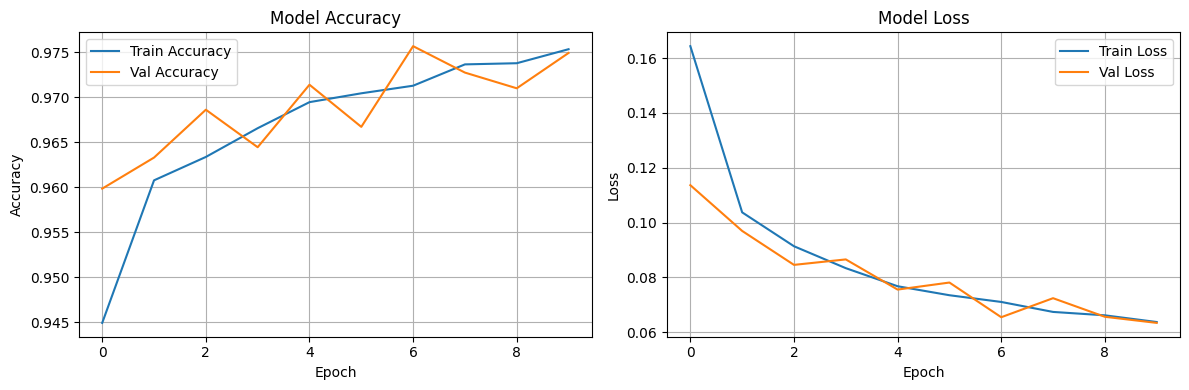

In [18]:
import matplotlib.pyplot as plt

# Plot Accuracy
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()